**Cell 1: ติดตั้งไลบรารีที่จำเป็น**

In [ ]:
# 1. ติดตั้งไลบรารี (หากยังไม่ได้ติดตั้งใน session นี้ ให้ uncomment บรรทัดล่างครับ)
!pip install -q xee geemap xarray shapely matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.2 MB/s eta 0:00:00


กำลังคำนวณขนาดพื้นที่เพาะปลูกจากดาวเทียม...
✅ พื้นที่เกษตรกรรมจริง (ตัดภูเขาออกแล้ว): 1,930,794.48 ไร่ (3,089,271,174.78 ตร.ม.)
กำลังดึงข้อมูล ET เข้าสู่ Xarray (อาจใช้เวลาสักครู่)...


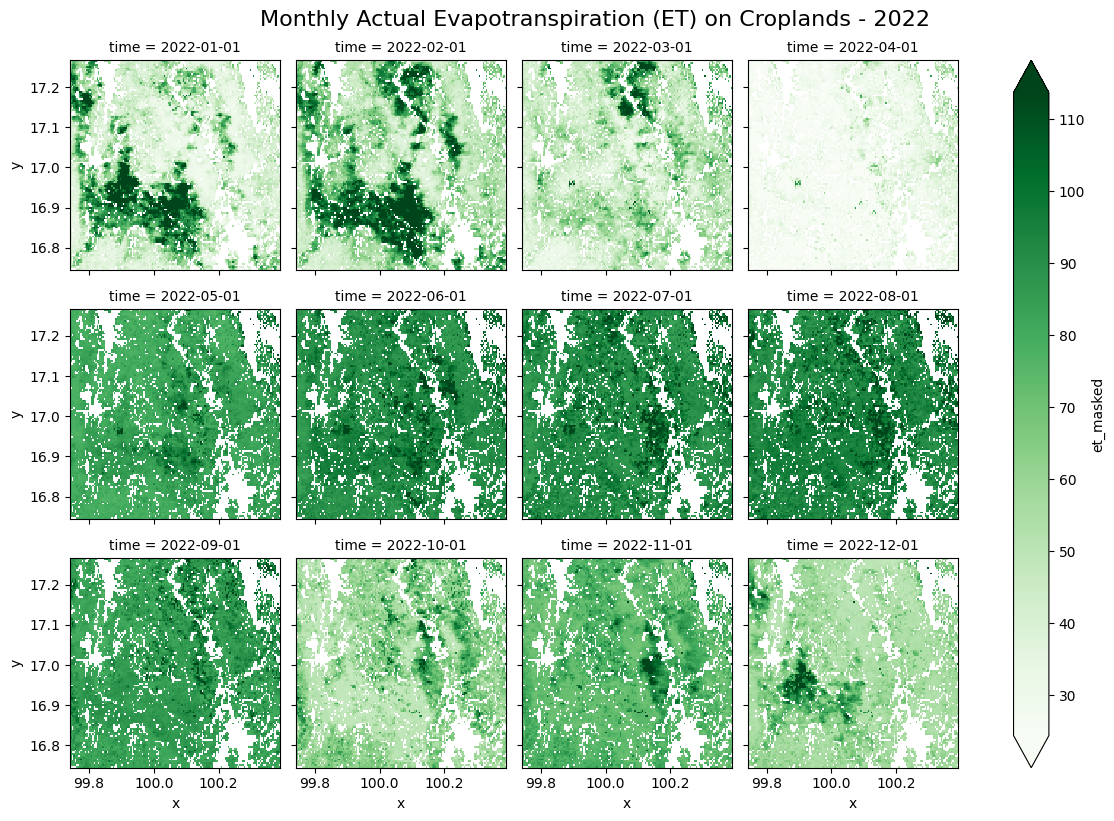


สรุปปริมาตรการใช้น้ำของพืช (Water Consumption) ปี 2022
  Month  Avg ET (mm) Volume (m³ - คิว)
2022-01    57.119999    176,458,592.00
2022-02    69.470001    214,603,520.00
2022-03    52.090000    160,925,984.00
2022-04    29.709999     91,772,264.00
2022-05    84.180000    260,054,144.00
2022-06    93.139999    287,735,520.00
2022-07    93.529999    288,930,080.00
2022-08    95.800003    295,957,600.00
2022-09    86.750000    267,992,784.00
2022-10    61.970001    191,449,872.00
2022-11    77.019997    237,936,384.00
2022-12    61.009998    188,480,640.00
--------------------------------------------------
💧 ปริมาตรน้ำที่พืชใช้รวมทั้งปี 2022: 2,662,297,600.00 ลูกบาศก์เมตร (คิว)


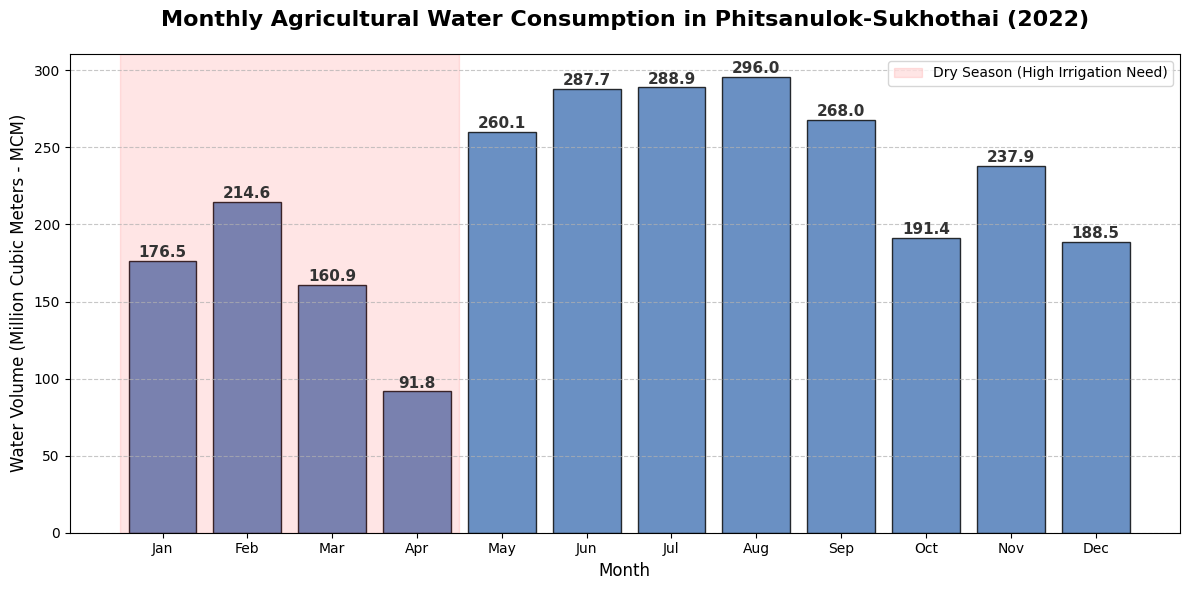

In [ ]:
# 1. ติดตั้งไลบรารี (หากยังไม่ได้ติดตั้งใน session นี้ ให้ uncomment บรรทัดล่างครับ)
# !pip install -q xee geemap xarray shapely matplotlib pandas

import ee
import geemap
import xarray as xr
import matplotlib.pyplot as plt
import shapely
from xee import helpers
import pandas as pd

# ยืนยันตัวตน GEE (เปลี่ยน 'your-project-id' เป็นชื่อโปรเจกต์ของคุณ)
ee.Authenticate() # หากล็อกอินแล้วคอมเมนต์ทิ้งได้ครับ
ee.Initialize(project='ee-end-to-end-gee')

# ==========================================
# 2. กำหนดพื้นที่ (ตามพิกัดใหม่ของคุณ)
# ==========================================
min_lon, min_lat = 100.16119010692728,
          16.795978728481742
max_lon, max_lat = 100.38929006606298, 17.266023831183105

roi_ee = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
aoi_shapely = shapely.geometry.box(min_lon, min_lat, max_lon, max_lat)

# ==========================================
# 3. คำนวณพื้นที่เพาะปลูกแบบอัตโนมัติ (เพิ่ม Land Cover Mask ตัดภูเขา)
# ==========================================
print("กำลังคำนวณขนาดพื้นที่เพาะปลูกจากดาวเทียม...")

# 3.1 หาพื้นที่พืชที่เขียวจัด (NDVI > 0.5)
ndvi_col = ee.ImageCollection("MODIS/061/MOD13A2").select('NDVI').filterDate('2022-01-01', '2022-12-31')
ndvi_max = ndvi_col.max().multiply(0.0001)
ndvi_mask = ndvi_max.gt(0.5)

# 3.2 [เพิ่มใหม่] ใช้ข้อมูล ESA WorldCover กรองเอาเฉพาะ "พื้นที่เกษตรกรรม (Cropland)"
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first()
crop_mask = worldcover.eq(40)

# 3.3 รวมหน้ากากเข้าด้วยกัน (ต้องเขียว และ ต้องเป็นแปลงเกษตร)
final_mask = ndvi_mask.And(crop_mask)

# 3.4 คำนวณขนาดพื้นที่ (ตารางเมตร) เฉพาะที่ผ่านเงื่อนไข final_mask
ndvi_pix_area = final_mask.multiply(ee.Image.pixelArea())
veg_area_dict = ndvi_pix_area.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi_ee,
    scale=500,
    maxPixels=1e10
).getInfo()

# เก็บค่าพื้นที่ลงตัวแปร Python
area_m2 = veg_area_dict['NDVI']
area_rai = area_m2 / 1600 # แปลงเป็นไร่
print(f"✅ พื้นที่เกษตรกรรมจริง (ตัดภูเขาออกแล้ว): {area_rai:,.2f} ไร่ ({area_m2:,.2f} ตร.ม.)")

# ==========================================
# 4. เตรียมข้อมูลการคายน้ำ (ET) รายเดือน และใส่หน้ากาก
# ==========================================
year = 2022
months = ee.List.sequence(1, 12)

def get_monthly_et(m):
    start = ee.Date.fromYMD(year, m, 1)
    end = start.advance(1, 'month')

    # ดึงค่าคายน้ำมา แล้วใช้ final_mask (ตัดภูเขา) บังคับไว้
    et_month = ee.ImageCollection("MODIS/061/MOD16A2GF") \
        .filterDate(start, end).filterBounds(roi_ee).select('ET') \
        .sum().multiply(0.1) \
        .updateMask(final_mask) \
        .set('system:time_start', start.millis()) \
        .set('month', m) \
        .rename('et_masked')

    return et_month

monthly_et_col = ee.ImageCollection.fromImages(months.map(get_monthly_et))

# ==========================================
# 5. ดึงข้อมูลเข้าสู่ Xarray และพล็อตแผนที่ 12 เดือน
# ==========================================
print("กำลังดึงข้อมูล ET เข้าสู่ Xarray (อาจใช้เวลาสักครู่)...")
grid_params = helpers.fit_geometry(
    geometry=aoi_shapely,
    grid_crs='EPSG:4326',
    grid_scale=(0.0045, -0.0045)
)

ds_et = xr.open_dataset(
    monthly_et_col,
    engine='ee',
    **grid_params
)

# พล็อต Spatial Distribution
ds_et.et_masked.plot(
    x='x', y='y',
    col='time', col_wrap=4,
    cmap='Greens', # ใช้สีเขียวแสดงปริมาณน้ำที่พืชคาย
    robust=True,
    figsize=(12, 8)
)
plt.suptitle('Monthly Actual Evapotranspiration (ET) on Croplands - 2022', y=1.02, fontsize=16)
plt.show()

# ==========================================
# 6. คำนวณสรุปปริมาตรน้ำรวม (Water Consumption Volume)
# ==========================================
print("\n" + "="*50)
print("สรุปปริมาตรการใช้น้ำของพืช (Water Consumption) ปี 2022")
print("="*50)

# หาค่าเฉลี่ย ET ทั้งพื้นที่ในแต่ละเดือน
et_mean_monthly = ds_et.et_masked.mean(dim=['x', 'y']).values

results = []
total_yearly_volume = 0

for i, et_val in enumerate(et_mean_monthly):
    month = i + 1

    # สมการ: ปริมาตร (m3) = ความลึกน้ำ (m) x พื้นที่ (m2)
    volume_m3 = (et_val / 1000) * area_m2
    total_yearly_volume += volume_m3

    results.append({
        "Month": f"2022-{month:02d}",
        "Avg ET (mm)": round(et_val, 2),
        "Volume (m³ - คิว)": f"{volume_m3:,.2f}"
    })

# แสดงผลเป็นตารางเพื่อให้ดูง่าย
df = pd.DataFrame(results)
print(df.to_string(index=False))

print("-" * 50)
print(f"💧 ปริมาตรน้ำที่พืชใช้รวมทั้งปี 2022: {total_yearly_volume:,.2f} ลูกบาศก์เมตร (คิว)")
print("=" * 50)

# ==========================================
# 7. พล็อตกราฟสรุปปริมาตรการใช้น้ำรายเดือน (Time-Series Chart)
# ==========================================
import numpy as np

# รายชื่อเดือนแบบย่อ
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# คำนวณปริมาตรน้ำ (คิว) จาก et_mean_monthly และแปลงเป็น "ล้านลูกบาศก์เมตร (MCM)"
volumes_m3 = [(val / 1000) * area_m2 for val in et_mean_monthly]
volumes_mcm = [v / 1_000_000 for v in volumes_m3]

# ตั้งค่ากราฟ
fig, ax = plt.subplots(figsize=(12, 6))

# พล็อตกราฟแท่ง (Bar Chart) ใช้โทนสีฟ้าสื่อถึงน้ำ
bars = ax.bar(months_labels, volumes_mcm, color='#4575b4', edgecolor='black', alpha=0.8)

# ตกแต่งกราฟ
ax.set_title('Monthly Agricultural Water Consumption in Phitsanulok-Sukhothai (2022)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Water Volume (Million Cubic Meters - MCM)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# เพิ่มตัวเลขกำกับไว้บนยอดเสาแต่ละต้น
for bar in bars:
    yval = bar.get_height()
    # วางตัวเลขเหนือแท่งกราฟ (Format ทศนิยม 1 ตำแหน่ง)
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# แรเงาพื้นหลังช่วงหน้าแล้ง (ม.ค. - เม.ย.) เพื่อเน้นจุดที่ต้องใช้น้ำชลประทานหนักๆ
ax.axvspan(-0.5, 3.5, color='red', alpha=0.1, label='Dry Season (High Irrigation Need)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

โค้ดชุดนี้คือการประยุกต์ใช้ขั้นสูงที่ต่อยอดมาจากการหาพื้นที่ชลประทาน โดยมีเป้าหมายเพื่อตอบคำถามสำคัญที่ว่า "พืชในพื้นที่นี้ ใช้น้ำไปทั้งหมดกี่ลูกบาศก์เมตร (คิว)?" แทนที่จะดูแค่ดัชนีหรือความเครียด โค้ดนี้จะคำนวณออกมาเป็น ปริมาตรน้ำจริง (Volume) เลย ซึ่งมีประโยชน์มหาศาลในการทำบัญชีสมดุลน้ำ (Water Accounting) ของกรมชลประทาน หรือการประเมินว่าอ่างเก็บน้ำที่มีอยู่จะเพียงพอต่อการเพาะปลูกหรือไม่นี่คือการถอดรหัสหลักการ วิธีการ และการตีความของโค้ดชุดนี้


**1. หลักการหลัก (Core Principle)**

หลักการของโค้ดนี้อิงตามสมการทางอุทกวิทยาที่เรียบง่ายแต่ทรงพลังครับ:ปริมาตรน้ำที่ถูกใช้ = ความลึกของน้ำที่พืชคายออก $\times$ ขนาดพื้นที่ปลูกพืชในทางคณิตศาสตร์ เพื่อให้ได้หน่วยเป็นลูกบาศก์เมตร ($m^3$) จะใช้สมการ:$$Volume\ (m^3) = \left( \frac{ET\ (mm)}{1000} \right) \times Area\ (m^2)$$(หมายเหตุ: ในบรรทัดสุดท้ายของโค้ดต้นฉบับไม่ได้หาร 1000 ซึ่งอาจทำให้หน่วยผลลัพธ์คลาดเคลื่อนไปจากลูกบาศก์เมตรจริง แนะนำให้หาร 1000 เพื่อแปลง mm เป็นเมตรเสมอครับ)


**2. วิธีการทำงานของโค้ด (Step-by-Step Methodology)**

โค้ดนี้แบ่งการทำงานออกเป็น 3 ส่วนหลัก:

ส่วนที่ 1: หาขนาดพื้นที่พืชพรรณ (Vegetation Area Calculation)โค้ดใช้ข้อมูลดาวเทียม MODIS ดึงค่าความเขียวสูงสุด (Max NDVI) ในรอบปีสร้างหน้ากาก (Mask) กรองเอาเฉพาะพื้นที่ที่เขียวมาก (NDVI > 0.5)ไฮไลต์สำคัญ: บรรทัด ee.Image.pixelArea() เป็นการสั่งให้ระบบคำนวณว่า พิกเซลสีเขียวแต่ละจุดบนโลกมีความกว้างยาวกี่ตารางเมตร แล้วนำมารวมกัน (reduceRegion) ผลลัพธ์ที่ได้คือ veg_area (พื้นที่เพาะปลูกรวมทั้งหมดในหน่วยตารางเมตร)

ส่วนที่ 2: ดึงข้อมูลการคายน้ำ (Evapotranspiration Retrieval)โค้ดนี้เปลี่ยนมาใช้ชุดข้อมูล USGS SSEBop MODIS ET ซึ่งเป็นโมเดลที่ใช้หลักการสมดุลพลังงาน (Energy Balance) ประเมินการคายน้ำจริง (Actual ET) ออกมาเป็นหน่วย "มิลลิเมตรต่อเดือน"นำข้อมูล ET นี้ไปคูณกับหน้ากากพืช (ds_et * ds_ndvi_thr) เพื่อบังคับให้วิเคราะห์เฉพาะปริมาณน้ำที่ระเหยออกจากแปลงเกษตรเท่านั้น ไม่นับรวมน้ำที่ระเหยจากถนนหรือหลังคาบ้าน

ส่วนที่ 3: คำนวณปริมาตรน้ำรวม (Total Water Consumption)หาค่าเฉลี่ยการคายน้ำของทั้งพื้นที่ (et_mean) บรรทัดสุดท้ายนำตัวเลขพื้นที่ มาคูณกับค่า ET รายเดือน เพื่อแปลง "ความลึกของน้ำ" ให้กลายเป็น "ปริมาตรรวม"

**3. การตีความหมาย (Interpretation)**

เมื่อรันโค้ดนี้เสร็จ ค่า wat_cons (Water Consumption) ที่ได้ออกมาในแต่ละเดือน จะเป็นตัวเลขมหาศาลหลักล้านหรือสิบล้านลูกบาศก์เมตร ตัวเลขนี้บอกอะไรเราบ้าง?

ประเมินประสิทธิภาพชลประทาน: ถ้านำปริมาตรน้ำรวมที่พืชใช้ (ได้จากดาวเทียม) ไปเทียบกับ ปริมาตรน้ำที่กรมชลประทานปล่อยออกจากเขื่อน (ข้อมูลจากมิเตอร์วัดน้ำ) คุณจะรู้ทันทีว่า "มีน้ำสูญหายไปในระบบส่งน้ำ (รั่วซึม/ระเหยตามคลอง) คิดเป็นกี่เปอร์เซ็นต์"

การทำ Water Footprint: ทราบได้ว่าในหนึ่งฤดูกาล พื้นที่เพาะปลูกทั้งจังหวัดนี้ ต้องใช้น้ำกี่ล้านคิวในการผลิตผลผลิตออกมา

การพยากรณ์น้ำล่วงหน้า: หากเห็นกราฟรายเดือน (จาก xarray plot) เราจะทราบว่าความต้องการใช้น้ำจะขึ้นไปพีกสูงสุด (Peak Demand) ในเดือนไหน เพื่อให้เจ้าหน้าที่เตรียมปรับแผนพร่องน้ำรอได้ทันท่วงที

สิ่งที่เราจะได้จากกราฟนี้:
แกน Y เป็นล้านคิว (MCM): ทำให้ตัวเลขดูง่าย (เช่น 50.5 ล้านคิว) ไม่ใช่เลขยาวเหยียด

ตัวเลขบนยอดเสา: ช่วยให้ผู้บริหารหรือทีมงานดูปุ๊บรู้ตัวเลขปั๊บ ไม่ต้องเพ่งเทียบกับแกน Y

แถบไฮไลต์หน้าแล้ง (สีแดงอ่อน): เพิ่มลูกเล่นแรเงาช่วงเดือน ม.ค. - เม.ย. เอาไว้ เพื่อเป็นการเน้นย้ำ (Highlight) ว่านี่คือช่วงเวลาที่ฝนทิ้งช่วง และปริมาตรน้ำแท่งสูงๆ ในโซนนี้ คือน้ำที่ต้องดึงมาจากเขื่อนหรือระบบชลประทานล้วนๆ